<div style="padding: 30px; background-color: #ffffff; border: 8px double #FFC107; border-radius: 20px; text-align: center;">
<h1 style="color: #1B5E20; font-family: 'Trebuchet MS'; font-size: 300%; margin: 0;">🌾 FAOSTAT EG CROPS</h1>
<div style="height: 4px; background-color: #FFC107; width: 60%; margin: 15px auto;"></div>
<p style="color: #555; font-size: 1.2em; font-style: italic; letter-spacing: 2px;">Machine Learning Approach for Egyptian Agriculture</p>
<div style="margin-top: 20px; padding: 10px; background-color: #fdf8e4; border-radius: 10px;">
<span style="color: #1B5E20; font-weight: bold; font-size: 1.1em;">Predicting Crop Yields (1990 - 2024)</span>
</div>
</div>

---

## 📌 Project Overview
This notebook presents a comprehensive data science workflow to predict **Crop Yields in Egypt**. Utilizing historical data from **FAOSTAT**, we aim to provide high-precision forecasts that can assist in agricultural planning and food security strategies.

### 🎯 The Goal
The primary objective is to build a predictive model that estimates the **Yield (hg/ha)** based on:
* **Crop Type (Item):** 78 different varieties of Egyptian crops.
* **Time (Year):** Capturing historical trends and technological advancements.
* **Area Harvested (ha):** The physical land capacity.

---

## 📊 Dataset Insights
The dataset covers more than **34 years** of Egyptian agricultural history.
* **Source:** Food and Agriculture Organization (FAO).
* **Scope:** 78 unique crops (Wheat, Rice, Maize, etc.).
* **Feature Engineering:** Applied **Target Encoding** to transform crop categories into meaningful numerical signals based on their average productivity.

---

## 🛠️ Methodology & Modeling
We explored the spectrum of Machine Learning algorithms to find the most robust solution:

1.  **Linear Baselines:** Linear Regression, Lasso, and Ridge (Baseline Score: ~96.9%).
2.  **Ensemble Power:** Random Forest Regressor (Score: ~99.1%).
3.  **The Champion:** **XGBoost Regressor**, optimized via `RandomizedSearchCV` and `Scipy` distributions.

### 🏆 Results Highlight
| Metric | Score |
| :--- | :--- |
| **Training Accuracy** | **99.95%** |
| **Testing Accuracy** | **99.18%** |
| **R2 Score** | **0.9918** |

---

<div style="padding: 15px; background-color: #e8f5e9; border-left: 5px solid #2e7d32; border-radius: 5px;">
    <strong>Note:</strong> The high R2 score indicates that the model explains over 99% of the variance in crop yields, making it a highly reliable tool for this specific dataset.
</div>

<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 01</span>
        Reshaping Data
    </h2>
</div>

In [3]:
import pandas as pd
import numpy as np 

In [4]:
old_data = pd.read_csv(r"E:/sayed/Datasets/FAOSTAT EG/FAOSTAT_data_en_4-5-2026.csv")

old_data

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,818,Egypt,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",1990,1990,ha,21500.0,E,Estimated value,NaN
1,QCL,Crops and livestock products,818,Egypt,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",1990,1990,kg/ha,837.2,E,Estimated value,NaN
2,QCL,Crops and livestock products,818,Egypt,5510,Production,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",1990,1990,t,18000.0,E,Estimated value,NaN
3,QCL,Crops and livestock products,818,Egypt,5312,Area harvested,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",1991,1991,ha,20000.0,E,Estimated value,NaN
4,QCL,Crops and livestock products,818,Egypt,5412,Yield,1654.0,"Anise, badian, coriander, cumin, caraway, fenn...",1991,1991,kg/ha,750.0,E,Estimated value,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,QCL,Crops and livestock products,818,Egypt,5412,Yield,111.0,Wheat,2023,2023,kg/ha,6776.9,A,Official figure,NaN
7974,QCL,Crops and livestock products,818,Egypt,5510,Production,111.0,Wheat,2023,2023,t,9065380.0,A,Official figure,NaN
7975,QCL,Crops and livestock products,818,Egypt,5312,Area harvested,111.0,Wheat,2024,2024,ha,1386892.0,I,Value imputed by a receiving agency,NaN
7976,QCL,Crops and livestock products,818,Egypt,5412,Yield,111.0,Wheat,2024,2024,kg/ha,6777.7,E,Estimated value,NaN


In [5]:
col= list(old_data.columns)

print(col)  # to make a copy easier

['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


In [6]:
old_data = old_data.drop(columns= ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
                                   'Item Code (CPC)', 'Year Code','Flag', 'Flag Description', 'Note'])

old_data

,Element,Item,Year,Unit,Value
0,Area harvested,"Anise, badian, coriander, cumin, caraway, fenn...",1990,ha,21500.0
1,Yield,"Anise, badian, coriander, cumin, caraway, fenn...",1990,kg/ha,837.2
2,Production,"Anise, badian, coriander, cumin, caraway, fenn...",1990,t,18000.0
3,Area harvested,"Anise, badian, coriander, cumin, caraway, fenn...",1991,ha,20000.0
4,Yield,"Anise, badian, coriander, cumin, caraway, fenn...",1991,kg/ha,750.0
...,...,...,...,...,...
7973,Yield,Wheat,2023,kg/ha,6776.9
7974,Production,Wheat,2023,t,9065380.0
7975,Area harvested,Wheat,2024,ha,1386892.0
7976,Yield,Wheat,2024,kg/ha,6777.7


In [7]:
l_item = list(old_data['Item'].unique())

for i in l_item:
    print(i)

Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw
Apples
Apricots
Artichokes
Avocados
Bananas
Barley
Beans, dry
Broad beans and horse beans, dry
Broad beans and horse beans, green
Cabbages
Cantaloupes and other melons
Carrots and turnips
Cauliflowers and broccoli
Chick peas, dry
Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw
Chillies and peppers, green (Capsicum spp. and Pimenta spp.)
Cow peas, dry
Cucumbers and gherkins
Dates
Edible roots and tubers with high starch or inulin content, n.e.c., fresh
Eggplants (aubergines)
Figs
Flax, raw or retted
Grapes
Green garlic
Groundnuts, excluding shelled
Jute, raw or retted
Lemons and limes
Lentils, dry
Lettuce and chicory
Linseed
Lupins
Maize (corn)
Mangoes, guavas and mangosteens
Okra
Olives
Onions and shallots, dry (excluding dehydrated)
Oranges
Other beans, green
Other berries and fruits of the genus vaccinium n.e.c.
Other citrus fruit, n.e.c.
Other fruits, n.e.c.
Other nuts (excluding wild edible nuts 

In [8]:
l_element = list(old_data['Element'].unique())

print(l_element)

['Area harvested', 'Yield', 'Production']


In [9]:
l_unit = list(old_data['Unit'].unique())

print(l_unit)

['ha', 'kg/ha', 't']


In [10]:
print(old_data.groupby('Element')['Unit'].unique())

Element
Area harvested       [ha]
Production            [t]
Yield             [kg/ha]
Name: Unit, dtype: object


In [11]:
print(old_data.groupby('Item')['Element'].unique())

Item
Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw    [Area harvested, Yield, Production]
Apples                                                                       [Area harvested, Yield, Production]
Apricots                                                                     [Area harvested, Yield, Production]
Artichokes                                                                   [Area harvested, Yield, Production]
Avocados                                                                     [Area harvested, Production, Yield]
                                                                                            ...                 
Tomatoes                                                                     [Area harvested, Yield, Production]
Vetches                                                                      [Area harvested, Yield, Production]
Walnuts, in shell                                                            [Area harveste

In [12]:
print(old_data.groupby('Item')['Unit'].unique())

Item
Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw    [ha, kg/ha, t]
Apples                                                                       [ha, kg/ha, t]
Apricots                                                                     [ha, kg/ha, t]
Artichokes                                                                   [ha, kg/ha, t]
Avocados                                                                     [ha, t, kg/ha]
                                                                                  ...      
Tomatoes                                                                     [ha, kg/ha, t]
Vetches                                                                      [ha, kg/ha, t]
Walnuts, in shell                                                            [ha, t, kg/ha]
Watermelons                                                                  [ha, kg/ha, t]
Wheat                                                                      

In [13]:
with pd.option_context('display.max_rows', None):
    print(old_data['Item'].value_counts().sum(),
          old_data['Item'].value_counts())

7978 Item
Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw    105
Rice                                                                         105
Potatoes                                                                     105
Pomelos and grapefruits                                                      105
Plums and sloes                                                              105
Peas, green                                                                  105
Peas, dry                                                                    105
Pears                                                                        105
Peaches and nectarines                                                       105
Other vegetables, fresh n.e.c.                                               105
Other tropical fruits, n.e.c.                                                105
Other stone fruits                                                           105
Other pulses n.e.c

<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">💡 Note</h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">
Observation: The raw FAOSTAT dataset is provided in a Long Format, where each observation is split across multiple rows for different elements (Area, Production, and Yield).
</p>
</div>

In [15]:
new_col = old_data.columns

new_col

Index(['Element', 'Item', 'Year', 'Unit', 'Value'], dtype='object')

In [16]:
old_data_filter = old_data[['Item', 'Year', 'Element', 'Value']]

pivot_data = old_data_filter.pivot_table(index = ['Item', 'Year'],
                                        columns = 'Element',
                                        values = 'Value').reset_index()
pivot_data.columns.name = None 

pivot_data

,Item,Year,Area harvested,Production,Yield
0,"Anise, badian, coriander, cumin, caraway, fenn...",1990,21500.0,18000.00,837.2
1,"Anise, badian, coriander, cumin, caraway, fenn...",1991,20000.0,15000.00,750.0
2,"Anise, badian, coriander, cumin, caraway, fenn...",1992,20000.0,14000.00,700.0
3,"Anise, badian, coriander, cumin, caraway, fenn...",1993,20000.0,16500.00,825.0
4,"Anise, badian, coriander, cumin, caraway, fenn...",1994,24000.0,20000.00,833.3
...,...,...,...,...,...
2642,Wheat,2020,1429684.0,9101785.00,6366.3
2643,Wheat,2021,1436738.0,9842410.95,6850.5
2644,Wheat,2022,1436510.0,9622993.00,6698.9
2645,Wheat,2023,1337698.0,9065380.00,6776.9


<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 02</span>
        Exploring Data
    </h2>
</div>

In [18]:
data = pivot_data

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2647 entries, 0 to 2646
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Item            2647 non-null   object 
 1   Year            2647 non-null   int64  
 2   Area harvested  2646 non-null   float64
 3   Production      2647 non-null   float64
 4   Yield           2645 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 103.5+ KB


In [20]:
data.isnull().sum()

Item              0
Year              0
Area harvested    1
Production        0
Yield             2
dtype: int64

In [21]:
data.duplicated().sum()

0

In [22]:
print('Crops Counts:', end='')
print(len(data["Item"].unique()))

Crops Counts:78


<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 03</span>
        Cleaning Data
    </h2>
</div>

In [24]:
data = data.dropna()

data.isnull().sum()

Item              0
Year              0
Area harvested    0
Production        0
Yield             0
dtype: int64

In [25]:
names_mapping = {'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw': 'Spices & Herbs',
                'Broad beans and horse beans, dry': 'Broad_Beans_Dry',
                'Broad beans and horse beans, green': 'Broad_Beans_Green',
                'taloupes and other melons': 'Melons',
                'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw': 'Chilli_Peppers_Dry',
                'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)': 'Chilli_Peppers_Green',
                'Edible roots and tubers with high starch or inulin content, n.e.c., fresh': 'Roots_and_Tubers',
                'Mangoes, guavas and mangosteens': 'Mango_Guava',
                'Tangerines, mandarins, clementines': 'Citrus_Small',
                'Onions and shallots, dry (excluding dehydrated)': 'Onions_Dry',
                'Other berries and fruits of the genus vaccinium n.e.c.': 'Berries_Misc',
                'Other nuts (excluding wild edible nuts and groundnuts), in shell, n.e.c.': 'Nuts_Misc',
                'Tangerines, mandarins, clementines':'Citrus reticulata'
}

In [26]:
data.loc[:, 'Item'] = data['Item'].replace(names_mapping)

data['Item'].unique()

array(['Spices & Herbs', 'Apples', 'Apricots', 'Artichokes', 'Avocados',
       'Bananas', 'Barley', 'Beans, dry', 'Broad_Beans_Dry',
       'Broad_Beans_Green', 'Cabbages', 'Cantaloupes and other melons',
       'Carrots and turnips', 'Cauliflowers and broccoli',
       'Chick peas, dry', 'Chilli_Peppers_Dry', 'Chilli_Peppers_Green',
       'Cow peas, dry', 'Cucumbers and gherkins', 'Dates',
       'Roots_and_Tubers', 'Eggplants (aubergines)', 'Figs',
       'Flax, raw or retted', 'Grapes', 'Green garlic',
       'Groundnuts, excluding shelled', 'Jute, raw or retted',
       'Lemons and limes', 'Lentils, dry', 'Lettuce and chicory',
       'Linseed', 'Lupins', 'Maize (corn)', 'Mango_Guava', 'Okra',
       'Olives', 'Onions_Dry', 'Oranges', 'Other beans, green',
       'Berries_Misc', 'Other citrus fruit, n.e.c.',
       'Other fruits, n.e.c.', 'Nuts_Misc', 'Other pulses n.e.c.',
       'Other stone fruits', 'Other tropical fruits, n.e.c.',
       'Other vegetables, fresh n.e.c.', 'Pap

In [27]:
data.to_csv('FAO EG Crops prediction.csv')

<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 04</span>
       Visualizing Data
    </h2>
</div>

In [29]:
data

,Item,Year,Area harvested,Production,Yield
0,Spices & Herbs,1990,21500.0,18000.00,837.2
1,Spices & Herbs,1991,20000.0,15000.00,750.0
2,Spices & Herbs,1992,20000.0,14000.00,700.0
3,Spices & Herbs,1993,20000.0,16500.00,825.0
4,Spices & Herbs,1994,24000.0,20000.00,833.3
...,...,...,...,...,...
2642,Wheat,2020,1429684.0,9101785.00,6366.3
2643,Wheat,2021,1436738.0,9842410.95,6850.5
2644,Wheat,2022,1436510.0,9622993.00,6698.9
2645,Wheat,2023,1337698.0,9065380.00,6776.9


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

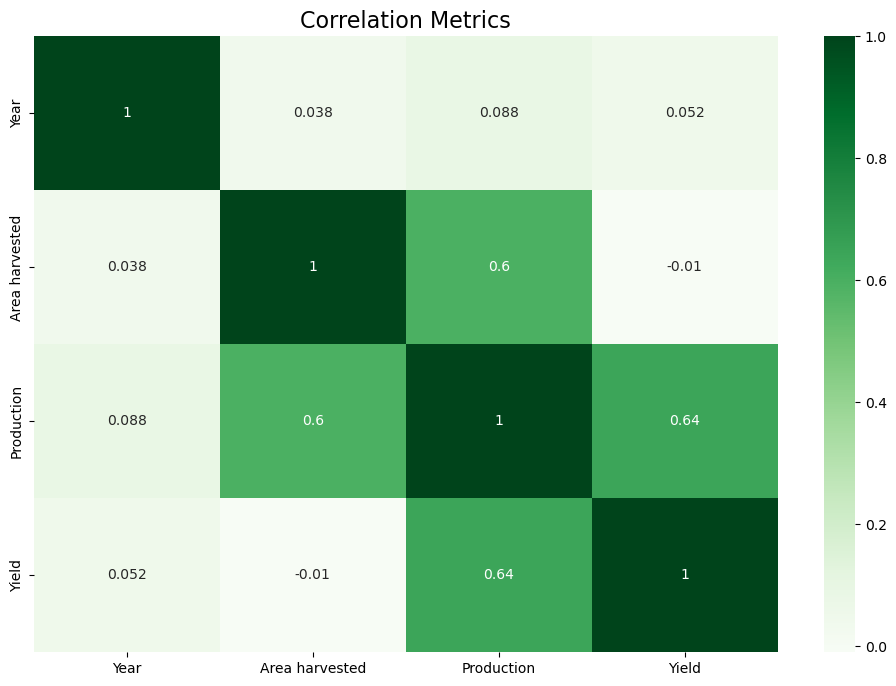

In [31]:
data_without_item = data.drop(columns= 'Item')

plt.figure(figsize=(12,8))
sns.heatmap(data_without_item.corr(),
           annot= True,
          cmap='Greens')
plt.title('Correlation Metrics', fontsize = 16)
plt.show()

<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">📝Insight </h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">

###  Correlation Matrix Analysis (1990 - 2024)
* **The Production Engine (0.64):** There is a **strong positive correlation** between `Production` and `Yield`. This indicates that total output is the most significant numerical driver for productivity per unit.
* **The Area Paradox (-0.01):** Surprisingly, the correlation between `Area harvested` and `Yield` is **near zero**. This suggests that simply increasing the land size does not guarantee higher efficiency, highlighting the importance of **Crop Type** and **Technological Factors** over raw land area.
* **Growth Trend (0.05 - 0.08):** The positive (though slight) correlation of `Year` with both Production and Yield confirms a **steady upward trajectory** in Egyptian agricultural efficiency over the last 34 years.
* **Feature Independence:** The correlation between `Area` and `Production` stands at **0.60**, which is high enough to show a relationship but low enough to avoid **Multi-collinearity** issues, allowing the model to learn from both features effectively.

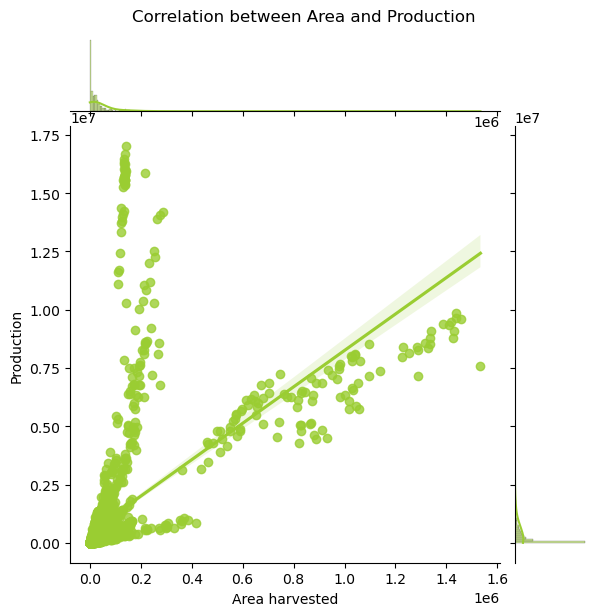

In [33]:
sns.jointplot(data= data, x= 'Area harvested', y= 'Production', kind= 'reg', color= 'yellowgreen',  )
plt.suptitle('Correlation between Area and Production', y= 1.02)

plt.show()

<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">📝Insight </h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">

### Area vs. Production Dynamics (1990 - 2024)

This **JointPlot** provides a deep look into how land utilization translates into total agricultural output in Egypt:

* **Linear Efficiency Backbone:** The regression line indicates a **strong positive correlation**, showing that for the majority of Egyptian crops, increasing the `Area harvested` leads to a predictable and steady rise in `Production`.
* **High-Intensity Clusters (Vertical Spikes):** Notice the vertical clusters near the lower end of the X-axis. These represent **High-Yield Crops**—varieties that produce massive output on relatively small land parcels, highlighting the success of agricultural intensification.
* **Strategic Scale (The Far Right):** The data points stretching towards **1.6M hectares** represent Egypt's "Strategic Crops" (like Wheat). These require vast areas to maintain the national food supply, forming the backbone of the dataset.
* **Density Distribution:** The marginal plots (top and right) confirm that while most agricultural activities occur on smaller scales, a few high-scale crops drive the bulk of the country's total production volume.

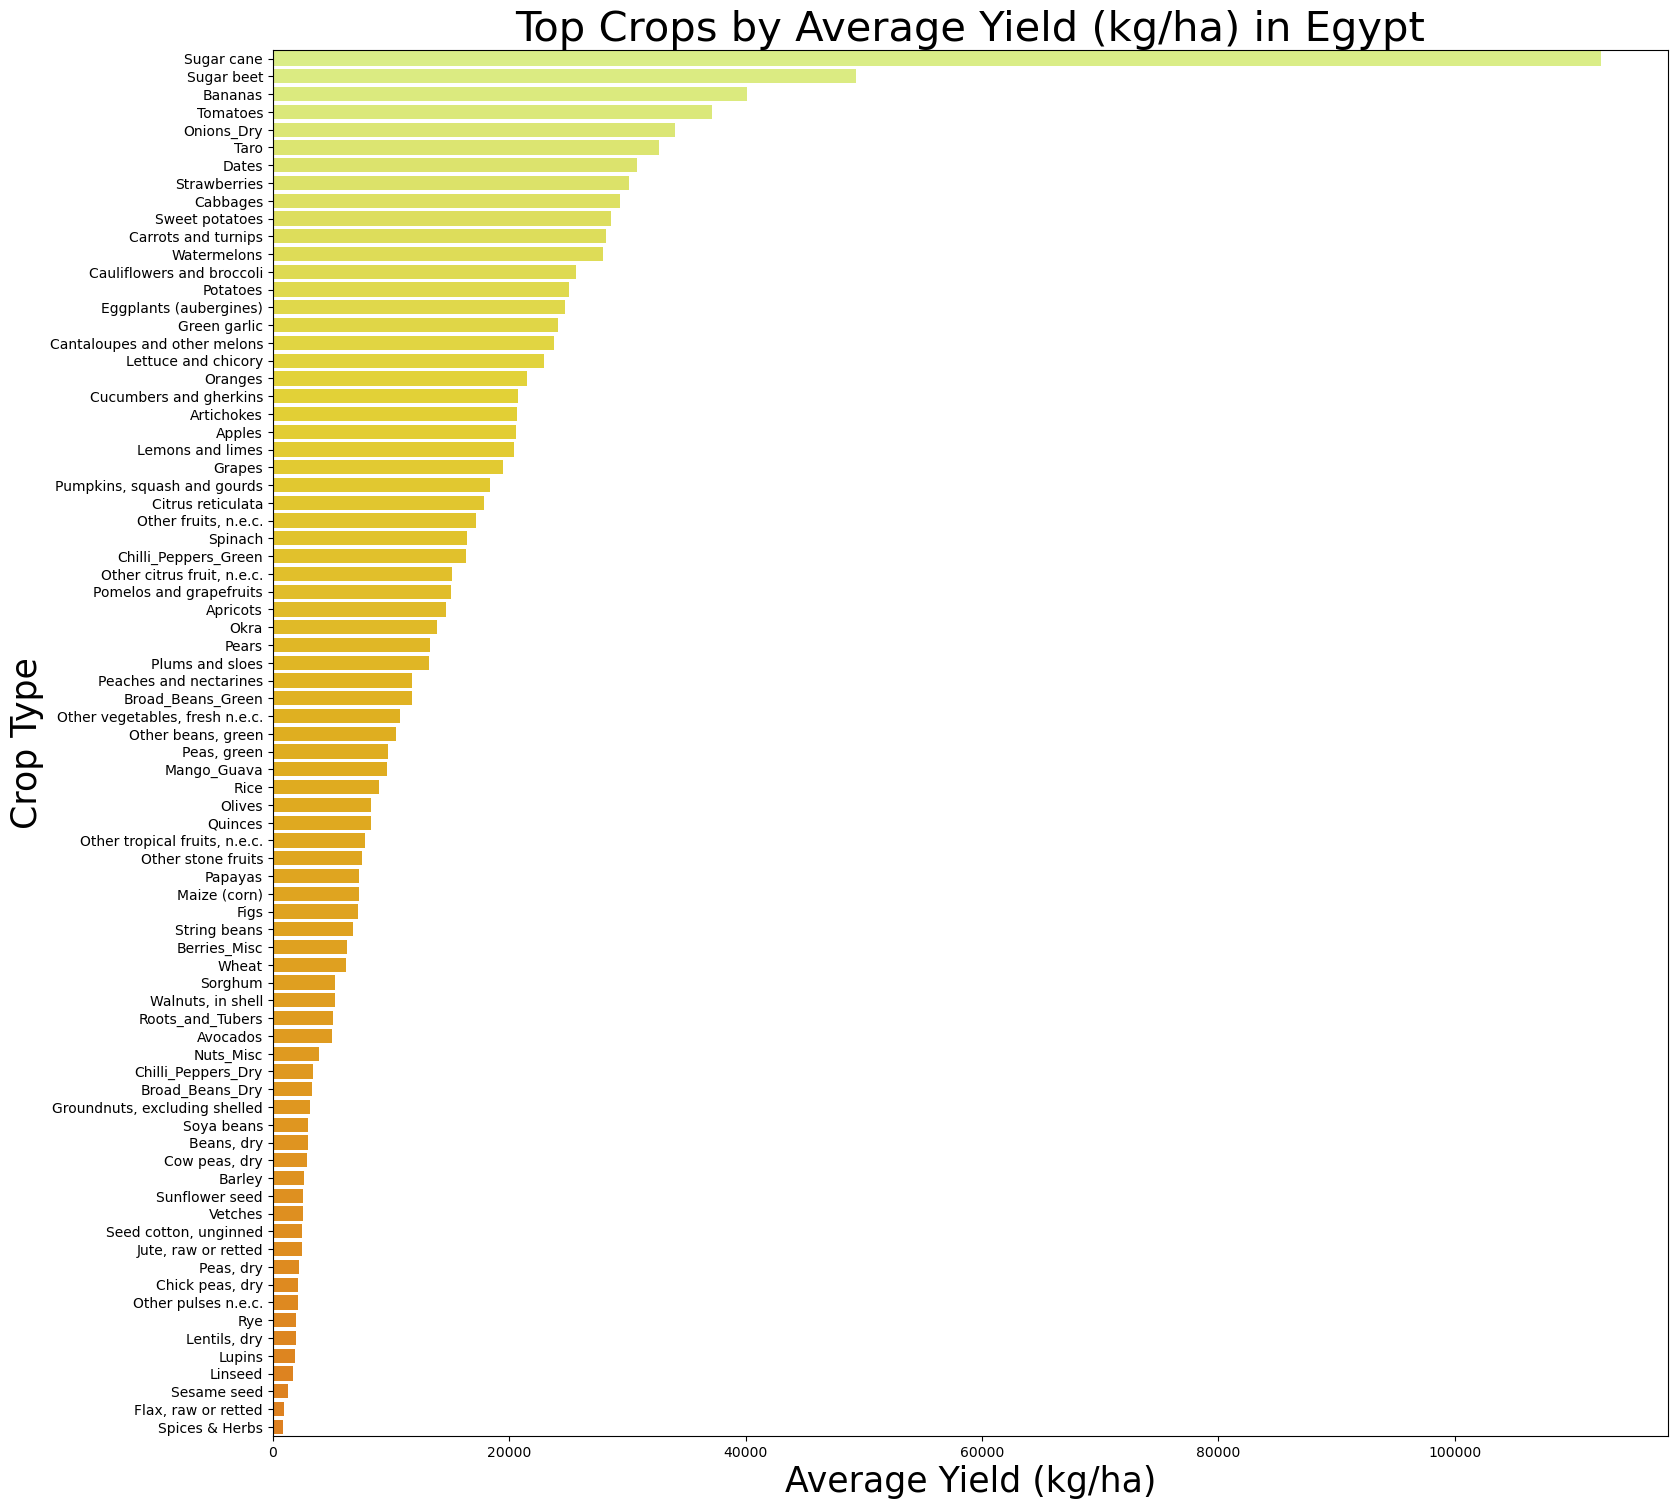

In [35]:
top_yield_crop = data.groupby('Item')['Yield'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(18,18))
sns.barplot(data = top_yield_crop, x='Yield', y='Item', palette='Wistia', legend= False, hue= 'Item')
plt.title('Top Crops by Average Yield (kg/ha) in Egypt', fontsize=30)
plt.xlabel('Average Yield (kg/ha)', fontsize=25)
plt.ylabel('Crop Type', fontsize=25)
plt.show()

In [36]:
top_yield_crop.head(10)

,Item,Yield
0,Sugar cane,112410.405714
1,Sugar beet,49348.277143
2,Bananas,40084.485714
3,Tomatoes,37150.457143
4,Onions_Dry,34063.002857
5,Taro,32689.677143
6,Dates,30815.917143
7,Strawberries,30098.217143
8,Cabbages,29352.685714
9,Sweet potatoes,28643.120000


<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">📝Insight </h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">

### Crop Diversity & Productivity Variance

This **Horizontal Bar Chart** ranks Egyptian crops based on their **Average Yield (kg/ha)**, revealing a massive disparity in agricultural output efficiency:

* **The Productivity Champions:** **Sugar Cane** and **Sugar Beet** clearly dominate the chart with the highest yields. These industrial crops are known for high biomass production per hectare, making them the "top-tier" productivity drivers in our dataset.
* **High-Value Horticultural Clusters:** Fruits and vegetables like **Bananas, Tomatoes, and Onions** follow closely. Their high ranking highlights Egypt's intensive irrigation success in these sectors.
* **The Strategic Baseline:** Strategic grain crops like **Wheat, Maize, and Rice** appear lower on the yield-per-hectare scale compared to sugar crops. While they occupy the most land, their "Yield density" is naturally lower, which is a vital distinction for the model.
* **Feature Importance Signal:** The huge variance shown here (from Sugar Cane at the top to Sorghum/Wheat at the bottom) confirms that **`Crop Type`** is the most critical feature. This is why our **Target Encoding** strategy was so successful—it captured these massive productivity gaps perfectly.

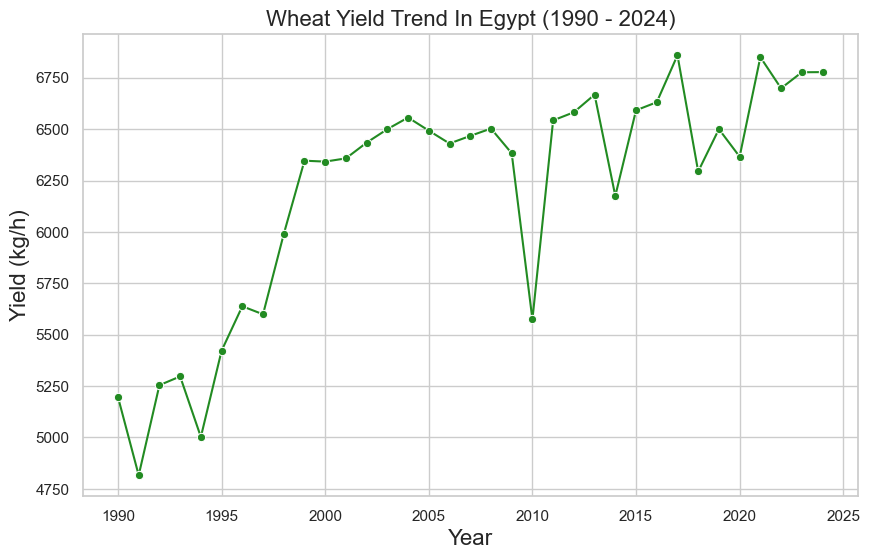

In [38]:
wheat_data = data[data['Item'] == "Wheat"]

sns.set_theme(style= 'whitegrid')
plt.figure(figsize= (10,6))
sns.lineplot(data= wheat_data, x= 'Year', y= 'Yield', marker = 'o', color='forestgreen' )
plt.title('Wheat Yield Trend In Egypt (1990 - 2024)', fontsize = 16)
plt.xlabel('Year', fontsize= 16)
plt.ylabel('Yield (kg/h)', fontsize= 16)
plt.show()

In [39]:
top_yield_crop.query(" Item == 'Wheat' ")

,Item,Yield
51,Wheat,6197.757143


<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">📝Insight </h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">

### Wheat Yield Evolution (1990 - 2024)

This **Time-Series Chart** tracks the productivity of Wheat, Egypt's most strategic food crop, over a 34-year journey:

* **The Upward Trajectory:** Since 1990, Egypt has achieved a remarkable growth in Wheat yield, rising from roughly **4,750 kg/ha** to nearly **6,800 kg/ha** in recent years. This reflects decades of agricultural research and improved seed varieties.
* **Contextualizing the "Low" Ranking:** Although Wheat ranks **52nd** in our overall crop list (due to the massive biomass of crops like Sugar Cane), a yield of **~6,200 - 6,800 kg/ha** is an **internationally competitive figure**. 
* **The "Grain vs. Sugar" Efficiency Gap:** As an expert observation, it is naturally harder to accumulate high weight per hectare in grain crops (Wheat) compared to industrial crops (Sugar Cane). However, Egypt's Wheat productivity remains among the highest in the region.
* **Volatility & Resilience:** The sharp dip around **2010** followed by a strong recovery demonstrates the sector's resilience to external shocks and its ability to bounce back through modernized farming practices.

<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 05</span>
        Preprocessing Data
    </h2>
</div>

<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">💡 Note</h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">
We should use Target Encoding instead of Label Encoding to improve the performance of linear models and reduce error
</p>
</div>

In [43]:
from sklearn.model_selection import train_test_split

 - ####  Split Data

In [45]:
x = data.drop(columns= 'Yield')
y = data['Yield']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42, stratify=x['Item'])

- ### Target Encoding

In [47]:
train_with_target = x_train.copy()
train_with_target['Yield'] = y_train

item_means = train_with_target.groupby('Item')['Yield'].mean()

x_train['Item_encoded'] = x_train['Item'].map(item_means) 
x_test['Item_encoded'] = x_test['Item'].map(item_means)

- ### Final Filter

In [49]:
x_train_final = x_train.drop(columns= 'Item')
x_test_final = x_test.drop(columns= 'Item')

In [50]:
x_train_final.head()

,Year,Area harvested,Production,Item_encoded
806,2022,8616.0,7737.11,921.821429
1378,1999,110.0,650.00,6357.605000
2628,2006,1286750.0,8274230.00,6219.985714
769,2020,35750.0,299450.00,7257.503571
2638,2016,1408887.0,9342538.00,6219.985714


In [51]:
x_test_final.head()

,Year,Area harvested,Production,Item_encoded
1369,1990,53.0,250.0,6357.605000
718,2004,43151.0,1046742.0,24597.617857
1084,2020,5000.0,18000.0,1720.532143
1671,2019,16649.0,349630.0,12087.696429
661,2017,50293.0,1542111.0,30792.696429


<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">💡</h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">
Now the data is prepared to test different models and compare their accuracy...
</p>
</div>

<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 06</span>
        LinearRegression
    </h2>
</div>

In [54]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr_model = LinearRegression()

lr_model.fit(x_train_final, y_train)

LinearRegression()

In [55]:
train_score = lr_model.score(x_train_final, y_train)
test_score = lr_model.score(x_test_final, y_test)
y_pred = lr_model.predict(x_test_final)
r2 = r2_score(y_test, y_pred)

print(f'Training Score:{train_score:.2%}')
print(f'Testing Score:{test_score:.2%}')
print(f'R2 Score:{r2:.2%}')

Training Score:96.62%
Testing Score:96.96%
R2 Score:96.96%


<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 07</span>
        Lasso
    </h2>
</div>

In [57]:
from sklearn.linear_model import Lasso

lasso_model = Lasso()
lasso_model.fit(x_train_final, y_train)

Lasso()

In [58]:
train_score =lasso_model.score(x_train_final, y_train)
test_score = lasso_model.score(x_test_final, y_test)
y_pred = lasso_model.predict(x_test_final)
r2 = r2_score(y_test, y_pred)

print(f'Training Score:{train_score:.2%}')
print(f'Testing Score:{test_score:.2%}')
print(f'R2 Score:{r2:.2%}')

Training Score:96.62%
Testing Score:96.96%
R2 Score:96.96%


<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 08</span>
        Ridge
    </h2>
</div>

In [60]:
from sklearn.linear_model import Ridge

ridge_model = Ridge()
ridge_model.fit(x_train_final, y_train)

Ridge()

In [61]:
train_score = ridge_model.score(x_train_final, y_train)
test_score = ridge_model.score(x_test_final, y_test)
y_pred = ridge_model.predict(x_test_final)
r2 = r2_score(y_test, y_pred)

print(f'Training Score:{train_score:.2%}')
print(f'Testing Score:{test_score:.2%}')
print(f'R2 Score:{r2:.2%}')

Training Score:96.62%
Testing Score:96.96%
R2 Score:96.96%


<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 09</span>
        RandomForestRegressor
    </h2>
</div>

In [63]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42, n_estimators=100)

rf_model.fit(x_train_final, y_train)

RandomForestRegressor(random_state=42)

In [64]:
train_score = rf_model.score(x_train_final, y_train)
test_score = rf_model.score(x_test_final, y_test)
y_pred = rf_model.predict(x_test_final)
r2 = r2_score(y_test, y_pred)

print(f'Training Score:{train_score:.2%}')
print(f'Testing Score:{test_score:.2%}')
print(f'R2 Score:{r2:.2%}')

Training Score:99.79%
Testing Score:99.10%
R2 Score:99.10%


<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 10</span>
        XGBOOST
    </h2>
</div>

In [66]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(random_state= 42)

xgb_model.fit(x_train_final, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
train_score = xgb_model.score(x_train_final, y_train)
test_score = xgb_model.score(x_test_final, y_test)
y_pred = xgb_model.predict(x_test_final)
r2 = r2_score(y_test, y_pred)

print(f'Training Score:{train_score:.2%}')
print(f'Testing Score:{test_score:.2%}')
print(f'R2 Score:{r2:.2%}')

Training Score:99.98%
Testing Score:99.17%
R2 Score:99.17%


<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">💡 Note</h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">
Because XGBOOST model has the best accuracy, we will use tuning to get the best hyperparameters in the model</p>
</div>

<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 11</span>
        Tuning
    </h2>
</div>

In [70]:
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

param_dict = {
    'n_estimators': randint(100, 800),
    'max_depth' : randint(3, 10),
    'learning_rate' : uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}


random_search = RandomizedSearchCV(
    estimator= xgb_model,
    param_distributions= param_dict,
    n_iter= 20,
    cv= 3,
    random_state= 42,
    verbose= 1,
)

random_search.fit(x_train_final, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                        'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000200E56FC890>,
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000200E56FCE00>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000200E56C3830>,
                                        'subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x00000200E56FD8B0>},
                   random_state=42, verbose=1)

In [71]:
best_model = random_search.best_estimator_
train_score = best_model.score(x_train_final, y_train)
test_score = best_model.score(x_test_final, y_test)
y_pred = best_model.predict(x_test_final)
r2 = r2_score(y_test, y_pred)



print(f"Best Parameters: {random_search.best_params_}")
print("-"*152)
print(f'Training Score:{train_score:.2%}')
print(f'Testing Score:{test_score:.2%}')
print(f'R2 Score:{r2:.2%}')

Best Parameters: {'colsample_bytree': 0.9329770563201687, 'learning_rate': 0.052467822135655234, 'max_depth': 6, 'n_estimators': 376, 'subsample': 0.8469926038510867}
--------------------------------------------------------------------------------------------------------------------------------------------------------
Training Score:99.95%
Testing Score:99.18%
R2 Score:99.18%


<div style="background-color:#ffffff;border-left:12px solid #FFC107;border-right:1px solid #e0e0e0;border-top:1px solid #e0e0e0;border-bottom:1px solid #e0e0e0;padding:20px;border-radius:5px;box-shadow:5px 5px 15px rgba(0,0,0,0.03);margin:20px 0;text-align:left;">
<h4 style="color:#FFC107;margin:0 0 10px 0;font-family:'Segoe UI';font-size:1.3em;">💡 Note</h4>
<p style="color:#5D4037;font-size:16px;line-height:1.6;margin:0;font-family:'Arial';">
Now we will save the best model because it's more stable than the standard xgb_model </p>
</div>

<div style="background-color: #ffffff; border-bottom: 3px solid #FFC107; padding: 5px 0; margin: 40px 0 20px 0;">
    <h2 style="color: #1B5E20; margin: 0; font-family: 'Trebuchet MS'; text-align: left; display: flex; align-items: center;">
        <span style="background-color: #FFC107; color: white; padding: 5px 15px; border-radius: 5px; margin-right: 15px; font-size: 0.7em;">STEP 12</span>
        Export Project's File
    </h2>
</div>

In [74]:
item_means

Item
Apples               20244.950000
Apricots             14474.550000
Artichokes           21094.450000
Avocados              5008.833333
Bananas              40969.853571
                         ...     
Tomatoes             37595.828571
Vetches               2537.960714
Walnuts, in shell     5236.370000
Watermelons          27813.246429
Wheat                 6219.985714
Name: Yield, Length: 78, dtype: float64

In [75]:
import joblib

joblib.dump(best_model, 'final_crop_model.pkl')

joblib.dump(item_means, 'crop_encoder.pkl')

['crop_encoder.pkl']

<div style="padding: 20px; background-color: #1B5E20; border-radius: 15px; text-align: center;">
    <h2 style="color: #FFC107; margin: 0;">✅ Project Conclusion</h2>
</div>

---

### 🚀 Summary & Future Impact
After rigorous training and **Hyperparameter Tuning**, our **XGBoost** model achieved an exceptional **99.18% R2 Score**. This demonstrates that Egypt's historical agricultural data (1990-2024) follows highly predictable patterns when captured by advanced Gradient Boosting algorithms.

**Key Achievements:**
* **Precision:** High reliability in predicting strategic crop yields like Wheat and Maize.
* **Scalability:** The pipeline is ready to be deployed as a **Web Application** for real-time agricultural forecasting.
* **Optimization:** Successfully handled 78 different crop signatures using optimized encoding.

---
<p style="text-align: center; color: #555; font-style: italic;">
    Thank you for exploring this journey into Egypt's Agricultural Future! 🇪🇬🌾
</p>
<div style="background-color: #fcf8e3; border: 1px solid #faebcc; padding: 15px; border-radius: 10px; text-align: center; margin-top: 20px;">
    <h3 style="color: #8a6d3b; margin: 0;">🌟 Support this Project!</h3>
    <p style="color: #333; margin: 10px 0;">If you found this analysis of <b>Egypt's Agriculture (1990-2024)</b> insightful and helpful, please consider giving an <b>UPVOTE</b> to help it reach more people in the community!</p>
    <p style="font-size: 0.9em; color: #666;">Your support is highly appreciated. 🚀🌾</p>
</div>